<a href="https://colab.research.google.com/github/dmdevinc/Shollenberger-wetland-project/blob/main/Shollenberger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shollenberger Project, 2026

How does surface water extent change seasonally in a tidal wetland?

Tools:
- geemap: python package for google earth engine connection
- sentinel-2: satellite imagery

## Packages and Set Up

In [1]:
# Install geemap
# info: https://pypi.org/project/geemap/
# pip install geemap

# Create a Google Earth Engine project and set up API
# info: https://colab.research.google.com/github/google/earthengine-community/blob/master/guides/linked/ee-api-colab-setup.ipynb#scrollTo=tRPULejJhBSl$0

In [47]:
# Import
import ee # google earth engine
import geemap

# Initialize the google earth enginge library
ee.Initialize(project='shollenberger')

# Define Shollenberger coordinates
shollenberger_pt = ee.Geometry.Point([-122.598555, 38.224888]) # single center point
# polgyon following 2 mile walking path
shollenberger_poly = ee.Geometry.Polygon([[
    [-122.5992786632553, 38.22787299030232],
    [-122.5995057705725, 38.22775678138207],
    [-122.5997720031113, 38.22778855180979],
    [-122.6007447555558, 38.22836596136636],
    [-122.6009384595212, 38.2284017086013],
    [-122.6011914505686, 38.22832943374195],
    [-122.6023200289863, 38.22729595894701],
    [-122.6033523372485, 38.22625763185358],
    [-122.6035407969382, 38.22602611353297],
    [-122.6037507225472, 38.22546372064151],
    [-122.6038939447859, 38.22497322173839],
    [-122.6041943829639, 38.22445645558448],
    [-122.6045497974704, 38.22412542340645],
    [-122.6051349534711, 38.22400798137608],
    [-122.6052809973936, 38.22389064782243],
    [-122.6051263447862, 38.22341572093131],
    [-122.6049534962698, 38.22299733108184],
    [-122.604705078659, 38.22262408638233],
    [-122.6034389928631, 38.22155762405112],
    [-122.6032220532315, 38.22145907648089],
    [-122.6027316330767, 38.22127285774164],
    [-122.6022224804258, 38.2212464607665],
    [-122.6018052846393, 38.22129731981555],
    [-122.6012044080092, 38.22142287769795],
    [-122.6006274690496, 38.2213722132961],
    [-122.5997868299647, 38.22113294199854],
    [-122.5991292065143, 38.22088512812334],
    [-122.5986956231249, 38.22087294298276],
    [-122.5970686967131, 38.22124335735403],
    [-122.5967591166156, 38.22147473749394],
    [-122.5963547978029, 38.22159013076342],
    [-122.5913845100954, 38.22704455629619],
    [-122.5914217050831, 38.22715776944863],
    [-122.5933484022996, 38.2279005887849],
    [-122.59350587967, 38.22790061423185],
    [-122.5937743661464, 38.22778519225154],
    [-122.5940382292535, 38.22777163795142],
    [-122.5957062383602, 38.22838683852322],
    [-122.5980032017346, 38.22906556223755],
    [-122.5982596565097, 38.22901986887084],
    [-122.5992786632553, 38.22787299030232]  # closes the polygon
]])

## Practice with Geemap

Pull information from Google Earth Enginge and create an basic interactive map.

In [48]:
# Print ground surface height (elevation) of a given coordinate
dem = ee.Image('USGS/SRTMGL1_003') # NASA/USGS elevation dataset covering the entire Earth

xy = ee.Geometry.Point([-122.577829, 37.929088]) # Mt Tam coordinates
elev = dem.sample(xy, 30).first().get('elevation').getInfo() # at this coordinate, what's the elevation value in this image?
print('Mount Tamalpias elevation (m):', elev)

elev = dem.sample(shollenberger_pt, 30).first().get('elevation').getInfo()
print('Shollenberger elevation (m):', elev)

Mount Tamalpias elevation (m): 763
Shollenberger elevation (m): -2


In [ ]:
# Create a basic interactive map with elevations

# Set visualization parameters
vis_params = {
  'min': 0,
  'max': 4000,
  'palette': ['006633', 'E5FFCC', '662A00', 'D8D8D8', 'F5F5F5']}

# Create a map object
m = geemap.Map(center=[20, 0], zoom=3)

# Add the elevation model to the map object
m.add_ee_layer(dem.updateMask(dem.gt(0)), vis_params, 'DEM')

# Display the map
display(m)

## Normalized Difference Water Index (NDWI)

Water and land reflect light differently.
- Visible Green Wavelengths (Green)
- Invisible Near-Infared Light (NIR)

Vegetation abosrbs red light for photosynthesis byt bounces back NIR
Water absorbs almonst all NIR
Dry soil reflects back Green and NIR back relatively evenly

Normalized Difference Water Index (NDWI), remote sensing index that helps us determine where NIR is really low, effectively indicating where moisture exists.

formula: (Green - NIR) / (Green + NIR)

In this project we will look at for each month, which pixels over Shollenberger have very low NIR, then count them. More low-NIR pixels = more water surface. So let's practice using geemap to pull NIR data.

The downside of this Index is that it is sensitive to built structures and can therefore over estimate water body size. It's also sensitive to cloud cover, which makes satellite imagery unreadable.

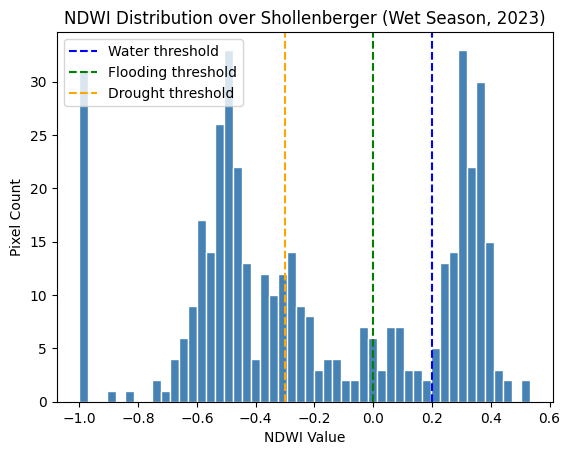

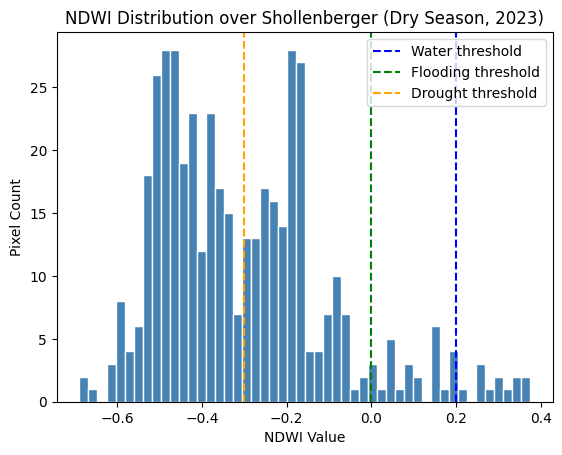

In [40]:
# Explore NDWI of Shollenberger

# Load and Filter Sentinel 2 imagery
img = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')  # load collection
    .filterBounds(shollenberger_poly)  # filter by location
    .filterDate('2023-01-01', '2023-03-31') # select date range (random for practice)
    .sort('CLOUDY_PIXEL_PERCENTAGE')  # rank by cloud cover
    .first())  # grab least cloudy image

# Calculate NDWI
ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI') # B3=Green, B8=NIR

# Sample 500 points
samp_fc = ndwi.sample(region=shollenberger_poly, scale=10, numPixels=500) # randomly sample 500 points at a 10 meter resolution
samp_dict = samp_fc.reduceColumns(ee.Reducer.toList(), ['NDWI']) # organize into a list
samp_data = ee.List(samp_dict.get('list')).getInfo() # pulls list from Google servers into Python

# Plot as histogram
import matplotlib.pyplot as plt
# makes 50 bins across the -1 to 1 range and counts how many pixels fall in each
plt.hist(samp_data, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0.2, color='blue', linestyle='--', label='Water threshold')
plt.axvline(0.0, color='green', linestyle='--', label='Flooding threshold')
plt.axvline(-0.3, color='orange', linestyle='--', label='Drought threshold')
plt.xlabel('NDWI Value')
plt.ylabel('Pixel Count')
plt.title('NDWI Distribution over Shollenberger (Wet Season, 2023)')
plt.legend()
plt.show()

# Load and Filter Sentinel 2 imagery
img = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')  # load collection
    .filterBounds(shollenberger_poly)  # filter by location
    .filterDate('2023-07-01', '2023-09-30')  # select date range (random for practice)
    .sort('CLOUDY_PIXEL_PERCENTAGE')  # rank by cloud cover
    .first())  # grab least cloudy image

# Calculate NDWI
ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI') # B3=Green, B8=NIR

# Sample 500 points
samp_fc = ndwi.sample(region=shollenberger_poly, scale=10, numPixels=500) # randomly sample 500 points at a 10 meter resolution
samp_dict = samp_fc.reduceColumns(ee.Reducer.toList(), ['NDWI']) # organize into a list
samp_data = ee.List(samp_dict.get('list')).getInfo() # pulls list from Google servers into Python

# Plot as histogram
import matplotlib.pyplot as plt
# makes 50 bins across the -1 to 1 range and counts how many pixels fall in each
plt.hist(samp_data, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0.2, color='blue', linestyle='--', label='Water threshold')
plt.axvline(0.0, color='green', linestyle='--', label='Flooding threshold')
plt.axvline(-0.3, color='orange', linestyle='--', label='Drought threshold')
plt.xlabel('NDWI Value')
plt.ylabel('Pixel Count')
plt.title('NDWI Distribution over Shollenberger (Dry Season, 2023)')
plt.legend()
plt.show()


# Interpretation:
# Three threshold lines visualize which categories the 500 pixels fall into
# Pixels to the right of the blue line (>0.2) are open water ("pond")
# Green dashed line (0.0) — Flooding/humidity, 0.0 and 0.2 are not quite open
# water but are saturated — think mudflats, wet marsh edge, waterlogged soil.
# Very relevant for a tidal wetland because this zone expands and contracts with
# the tide and season.
# Orange dashed line (-0.3) — Moderate drought boundary Pixels between -0.3 and
# 0.0 are non-aqueous surfaces — dry vegetation, upland areas, the dike trail
# you walk on. Most of the surrounding land will sit here.
# Everything to the left of -0.3 is drought/very dry surfaces. You probably
# won't see much of this at Shollenberger since it's a wetland, but you might
# see a few pixels from the parking lot or surrounding industrial area.
# The NDWI values correspond to the following ranges:
# 0,2 – 1 – Water surface,
# 0.0 – 0,2 – Flooding, humidity,
# -0,3 – 0.0 – Moderate drought, non-aqueous surfaces,
# -1 – -0.3 – Drought, non-aqueous surfaces

## Shollenberger Map

In [68]:
# Generate map — centered on Shollenberger
Map = geemap.Map(center=[38.2249, -122.5986], zoom=16)

# Sentinel-2 image filtered to your polygon
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(shollenberger_poly)
    .filterDate('2023-01-01', '2023-03-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .median())

# True color
vis_true = {'min': 0, 'max': 3000, 'bands': ['B4', 'B3', 'B2']}
Map.addLayer(s2, vis_true, 'True Color')

# NDWI
ndwi = s2.normalizedDifference(['B3', 'B8'])
vis_ndwi = {'min': -1, 'max': 1, 'palette': ['brown', 'white', 'blue']}
Map.addLayer(ndwi, vis_ndwi, 'NDWI')

# Add your polygon boundary so you can see it on the map
empty = ee.Image().byte()
outline = empty.paint(
    featureCollection=ee.FeatureCollection([ee.Feature(shollenberger_poly)]),
    color=1,
    width=3  # border width in pixels
)
Map.addLayer(outline, {'palette': 'blue'}, 'Shollenberger')

Map

Map(center=[38.2249, -122.5986], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [67]:
# Generate map — centered on Shollenberger
Map = geemap.Map(center=[38.2249, -122.5986], zoom=16)

# Sentinel-2 image filtered to your polygon
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(shollenberger_poly)
    .filterDate('2023-07-01', '2023-09-30')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .median())

# True color
vis_true = {'min': 0, 'max': 3000, 'bands': ['B4', 'B3', 'B2']}
Map.addLayer(s2, vis_true, 'True Color')

# NDWI
ndwi = s2.normalizedDifference(['B3', 'B8'])
vis_ndwi = {'min': -1, 'max': 1, 'palette': ['brown', 'white', 'blue']}
Map.addLayer(ndwi, vis_ndwi, 'NDWI')

# Add your polygon boundary so you can see it on the map
empty = ee.Image().byte()
outline = empty.paint(
    featureCollection=ee.FeatureCollection([ee.Feature(shollenberger_poly)]),
    color=1,
    width=3  # border width in pixels
)
Map.addLayer(outline, {'palette': 'red'}, 'Shollenberger')

Map

Map(center=[38.2249, -122.5986], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [ ]:
# STATIC MAP

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Export the NDWI image clipped to your polygon as a numpy array
ndwi_clipped = ndwi.clip(shollenberger_poly)

# Get the image as a numpy array
image_array = geemap.ee_to_numpy(
    ndwi_clipped,
    region=shollenberger_poly,
    scale=10
)

# Plot it
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    image_array[:, :, 0],
    cmap='RdYlBu',  # brown to blue through white
    vmin=-1,
    vmax=1
)

# Add colorbar
plt.colorbar(ax.images[0], ax=ax, label='NDWI Value')
ax.set_title('Shollenberger Water Extent — Wet Season 2023', fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.savefig('shollenberger_ndwi.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# exporting the map

## Monthly Seasonal Comparison

In [ ]:
# compare NDWI monthly to identify when shifts occur in hydrology